# GitHub Activity Analysis

Fetches commit, PR, and issue data across repos via the `gh` CLI and saves them as CSVs.  
Run the fetch cells once, then iterate on the analysis cells freely.

**Prerequisites:** `gh auth login` must already be done in your shell.

In [2]:
import subprocess
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
PUBLIC_IMG_DIR = Path('../src/content/blog/agentic-development')
PUBLIC_IMG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    """Save to both data/ and alongside the blog content for Astro's image pipeline."""
    plt.savefig(DATA_DIR / name, dpi=150, bbox_inches='tight')
    plt.savefig(PUBLIC_IMG_DIR / name, dpi=150, bbox_inches='tight')

In [3]:
import os, re

def gh_api(endpoint, paginate=True):
    """Call gh REST api, return parsed JSON."""
    env = {**os.environ, 'NO_COLOR': '1', 'GH_PAGER': '', 'CLICOLOR': '0'}
    cmd = ['gh', 'api'] + (['--paginate'] if paginate else []) + [endpoint]
    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        print(f'  Warning: {endpoint} → {result.stderr.strip()[:120]}')
        return []
    text = re.sub(r'\x1b\[[0-9;]*[mKHJ]', '', result.stdout).strip()
    if text.startswith('[') and '][' in text:
        text = '[' + text[1:-1].replace('][', ',') + ']'
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        print(f'  JSON parse error for {endpoint}: {repr(text[:120])}')
        return []

def gh_graphql(query, **variables):
    """Execute a GraphQL query via JSON stdin body, return the data dict."""
    env = {**os.environ, 'NO_COLOR': '1', 'GH_PAGER': '', 'CLICOLOR': '0'}
    body = json.dumps({'query': query, 'variables': variables})
    result = subprocess.run(
        ['gh', 'api', 'graphql', '--input', '-'],
        input=body, capture_output=True, text=True, env=env
    )
    if result.returncode != 0:
        print(f'  GraphQL error: {result.stderr.strip()[:200]}')
        return {}
    text = re.sub(r'\x1b\[[0-9;]*[mKHJ]', '', result.stdout).strip()
    try:
        return json.loads(text).get('data', {})
    except json.JSONDecodeError:
        print(f'  JSON parse error: {repr(text[:120])}')
        return {}

def graphql_to_df(outer_query, inner_query, get_connection, get_more_conn, to_row,
                  include_forks=False, allowed_owners=None):
    """
    Paginate viewer.repositories via GraphQL and collect rows into a DataFrame.

    outer_query    — fetches viewer.login + paginated viewer.repositories, each node
                     containing an inner connection (commits / PRs / issues)
    inner_query    — follow-up query for repos whose inner connection has >100 items;
                     receives $owner, $name, $cursor
    get_connection — repo_node  -> inner connection dict {nodes, pageInfo}
    get_more_conn  — data       -> inner connection dict from the follow-up query
    to_row         — (item, slug) -> dict for one DataFrame row
    allowed_owners — set of GitHub logins (user + owned orgs) to include; None = all

    Returns (df, repo_slugs, my_login).
    """
    rows, slugs = [], []
    my_login = ''
    repo_cursor = None

    while True:
        data = gh_graphql(outer_query, cursor=repo_cursor)
        viewer = data.get('viewer', {})
        if not my_login:
            my_login = viewer.get('login', '')

        repos_conn = viewer.get('repositories', {})
        for repo in repos_conn.get('nodes', []):
            if repo.get('isFork') and not include_forks:
                continue
            slug = repo['nameWithOwner']
            if allowed_owners and slug.split('/')[0] not in allowed_owners:
                continue
            if slug not in slugs:
                slugs.append(slug)

            conn = get_connection(repo) or {}
            for item in conn.get('nodes', []):
                rows.append(to_row(item, slug))

            pi = conn.get('pageInfo', {})
            inner_cursor = pi.get('endCursor') if pi.get('hasNextPage') else None
            while inner_cursor:
                owner, name = slug.split('/')
                more = gh_graphql(inner_query, owner=owner, name=name, cursor=inner_cursor)
                more_conn = get_more_conn(more) or {}
                for item in more_conn.get('nodes', []):
                    rows.append(to_row(item, slug))
                pi = more_conn.get('pageInfo', {})
                inner_cursor = pi.get('endCursor') if pi.get('hasNextPage') else None

        if not repos_conn.get('pageInfo', {}).get('hasNextPage'):
            break
        repo_cursor = repos_conn['pageInfo']['endCursor']

    return pd.DataFrame(rows), slugs, my_login

In [3]:
INCLUDE_FORKS = False  # set True to include forked repos

# Shared fragment for the outer repo loop (same for all three queries)
_REPOS_OUTER = """
  viewer {
    login
    repositories(
      first: 100
      after: $cursor
      ownerAffiliations: [OWNER, ORGANIZATION_MEMBER]
      privacy: PUBLIC
      orderBy: {field: PUSHED_AT, direction: DESC}
    ) {
      pageInfo { hasNextPage endCursor }
      nodes {
        nameWithOwner
        isFork
        %s
      }
    }
  }
"""

# additions/deletions are expensive to compute — use first:20 to avoid 502s
COMMITS_OUTER = ("query($cursor: String) {" + _REPOS_OUTER + "}") % """
        defaultBranchRef {
          target {
            ... on Commit {
              history(first: 20) {
                pageInfo { hasNextPage endCursor }
                nodes { oid message committedDate additions deletions author { name } }
              }
            }
          }
        }"""

COMMITS_MORE = """
query($owner: String!, $name: String!, $cursor: String!) {
  repository(owner: $owner, name: $name) {
    defaultBranchRef { target { ... on Commit {
      history(first: 20, after: $cursor) {
        pageInfo { hasNextPage endCursor }
        nodes { oid message committedDate additions deletions author { name } }
      }
    } } }
  }
}"""

PRS_OUTER = ("query($cursor: String) {" + _REPOS_OUTER + "}") % """
        pullRequests(first: 100, states: [OPEN, CLOSED, MERGED], orderBy: {field: CREATED_AT, direction: DESC}) {
          pageInfo { hasNextPage endCursor }
          nodes { number title state createdAt closedAt mergedAt isDraft body }
        }"""

PRS_MORE = """
query($owner: String!, $name: String!, $cursor: String!) {
  repository(owner: $owner, name: $name) {
    pullRequests(first: 100, after: $cursor, states: [OPEN, CLOSED, MERGED]) {
      pageInfo { hasNextPage endCursor }
      nodes { number title state createdAt closedAt mergedAt isDraft body }
    }
  }
}"""

ISSUES_OUTER = ("query($cursor: String) {" + _REPOS_OUTER + "}") % """
        issues(first: 100, states: [OPEN, CLOSED], orderBy: {field: CREATED_AT, direction: DESC}) {
          pageInfo { hasNextPage endCursor }
          nodes { number title state body createdAt closedAt author { login } comments { totalCount } }
        }"""

ISSUES_MORE = """
query($owner: String!, $name: String!, $cursor: String!) {
  repository(owner: $owner, name: $name) {
    issues(first: 100, after: $cursor, states: [OPEN, CLOSED]) {
      pageInfo { hasNextPage endCursor }
      nodes { number title state body createdAt closedAt author { login } comments { totalCount } }
    }
  }
}"""

## Fetch data

Commits use the GraphQL API (all repos + their history in one paginated query). PRs and issues use the REST API per repo."

In [4]:
# Fetch viewer login + orgs where viewer is an owner (admin role)
_identity = gh_graphql("""
query {
  viewer {
    login
    organizations(first: 100) {
      nodes { login viewerCanAdminister }
    }
  }
}
""")
my_login = _identity.get('viewer', {}).get('login', '')
_orgs = _identity.get('viewer', {}).get('organizations', {}).get('nodes', [])
owned_org_logins = {o['login'] for o in _orgs if o.get('viewerCanAdminister')}
ALLOWED_OWNERS = {my_login} | owned_org_logins

print(f'Login:      {my_login}')
print(f'Owned orgs: {owned_org_logins}')
print(f'Filtering to owners: {ALLOWED_OWNERS}')

Login:      thenomadlad
Owned orgs: {'indusbiomed', 'caramlops', 'NorrisGang', 'retrofit-ui'}
Filtering to owners: {'indusbiomed', 'thenomadlad', 'caramlops', 'NorrisGang', 'retrofit-ui'}


In [5]:
# ── Commits ──────────────────────────────────────────────────────────────────
def commit_row(item, slug):
    msg = item.get('message', '') or ''
    return {
        'repo': slug.split('/')[-1], 'slug': slug,
        'sha': item.get('oid', '')[:8],
        'date': item.get('committedDate', ''),
        'author': (item.get('author') or {}).get('name', ''),
        'message': msg.split('\n')[0][:120],
        'claude_coauthored': 'co-authored-by: claude' in msg.lower(),
        'is_merge': msg.startswith('Merge '),
        'additions': item.get('additions', 0) or 0,
        'deletions': item.get('deletions', 0) or 0,
    }

commits_df, repo_slugs, my_login = graphql_to_df(
    COMMITS_OUTER, COMMITS_MORE,
    get_connection=lambda r: (r.get('defaultBranchRef') or {}).get('target', {}).get('history'),
    get_more_conn=lambda d: d.get('repository', {}).get('defaultBranchRef', {}).get('target', {}).get('history'),
    to_row=commit_row,
    include_forks=INCLUDE_FORKS,
    allowed_owners=ALLOWED_OWNERS,
)
commits_df['date'] = pd.to_datetime(commits_df['date'], utc=True)
commits_df['year'] = commits_df['date'].dt.year
commits_df['month'] = commits_df['date'].dt.to_period('M')
commits_df['lines_changed'] = commits_df['additions'] + commits_df['deletions']
commits_df.to_csv(DATA_DIR / 'commits.csv', index=False)
print(f'{len(commits_df)} commits across {len(repo_slugs)} repos')
commits_df.head()

641 commits across 36 repos


/tmp/ipykernel_467230/4254056496.py:26: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  commits_df['month'] = commits_df['date'].dt.to_period('M')


,repo,slug,sha,date,author,message,claude_coauthored,is_merge,additions,deletions,year,month,lines_changed
0,adityadharacom,thenomadlad/adityadharacom,fc7dd778,2026-06-15 07:38:13+00:00,Aditya Dhara,Merge pull request #32 from thenomadlad/move_t...,False,True,932,985,2026,2026-06,1917
1,adityadharacom,thenomadlad/adityadharacom,0a1d69a5,2026-06-15 07:34:07+00:00,Someone Somewhere,"CI: drop Playwright e2e, run build instead",True,False,3,19,2026,2026-06,22
2,adityadharacom,thenomadlad/adityadharacom,e5c532cf,2026-06-15 07:26:00+00:00,Someone Somewhere,CI: add 20m timeout and cache Playwright browsers,True,False,7,0,2026,2026-06,7
3,adityadharacom,thenomadlad/adityadharacom,8e9399ed,2026-06-14 22:32:56+00:00,Someone Somewhere,Upgrade CI to Node 26 + pnpm 11 via corepack,True,False,59,44,2026,2026-06,103
4,adityadharacom,thenomadlad/adityadharacom,57d1572c,2026-06-14 22:08:13+00:00,Someone Somewhere,Working and updated,False,False,900,959,2026,2026-06,1859


In [6]:
# ── Pull Requests ─────────────────────────────────────────────────────────────
def pr_row(item, slug):
    body = item.get('body', '') or ''
    return {
        'repo': slug.split('/')[-1], 'slug': slug,
        'number': item.get('number'),
        'title': (item.get('title', '') or '')[:120],
        'state': (item.get('state', '') or '').lower(),
        'created_at': item.get('createdAt', ''),
        'closed_at': item.get('closedAt', ''),
        'merged_at': item.get('mergedAt', ''),
        'draft': item.get('isDraft', False),
        'body_length': len(body),
        'claude_mentioned': 'claude' in body.lower(),
    }

prs_df, _, _ = graphql_to_df(
    PRS_OUTER, PRS_MORE,
    get_connection=lambda r: r.get('pullRequests'),
    get_more_conn=lambda d: d.get('repository', {}).get('pullRequests'),
    to_row=pr_row,
    include_forks=INCLUDE_FORKS,
    allowed_owners=ALLOWED_OWNERS,
)
for col in ['created_at', 'closed_at', 'merged_at']:
    prs_df[col] = pd.to_datetime(prs_df[col], utc=True)
prs_df['time_to_merge_days'] = (
    (prs_df['merged_at'] - prs_df['created_at']).dt.total_seconds() / 86400
)
prs_df.to_csv(DATA_DIR / 'prs.csv', index=False)
print(f'{len(prs_df)} PRs')
prs_df.head()

100 PRs


,repo,slug,number,title,state,created_at,closed_at,merged_at,draft,body_length,claude_mentioned,time_to_merge_days
0,adityadharacom,thenomadlad/adityadharacom,32,Working and updated,merged,2026-06-14 22:08:50+00:00,2026-06-15 07:38:14+00:00,2026-06-15 07:38:14+00:00,False,0,False,0.395417
1,adityadharacom,thenomadlad/adityadharacom,30,Removed tag build condition,merged,2026-03-17 08:39:02+00:00,2026-03-17 08:42:10+00:00,2026-03-17 08:42:10+00:00,False,0,False,0.002176
2,adityadharacom,thenomadlad/adityadharacom,29,Removed mermaid and moved to netlify,merged,2026-03-17 08:15:04+00:00,2026-03-17 08:35:53+00:00,2026-03-17 08:35:52+00:00,False,0,False,0.014444
3,adityadharacom,thenomadlad/adityadharacom,28,Update deploy strategy,merged,2026-03-17 07:06:14+00:00,2026-03-17 07:10:42+00:00,2026-03-17 07:10:42+00:00,False,0,False,0.003102
4,adityadharacom,thenomadlad/adityadharacom,27,Move to solid,merged,2026-03-13 18:41:02+00:00,2026-03-17 06:37:58+00:00,2026-03-17 06:37:58+00:00,False,0,False,3.497870


In [7]:
# ── Issues ────────────────────────────────────────────────────────────────────
my_logins = {my_login}

def issue_row(item, slug):
    author = (item.get('author') or {}).get('login', '')
    body = item.get('body', '') or ''
    return {
        'repo': slug.split('/')[-1], 'slug': slug,
        'number': item.get('number'),
        'title': (item.get('title', '') or '')[:120],
        'state': (item.get('state', '') or '').lower(),
        'created_at': item.get('createdAt', ''),
        'closed_at': item.get('closedAt', ''),
        'author': author,
        'comments': (item.get('comments') or {}).get('totalCount', 0),
        'body_len': len(body),
        'is_mine': author in my_logins,
    }

issues_df, _, _ = graphql_to_df(
    ISSUES_OUTER, ISSUES_MORE,
    get_connection=lambda r: r.get('issues'),
    get_more_conn=lambda d: d.get('repository', {}).get('issues'),
    to_row=issue_row,
    include_forks=INCLUDE_FORKS,
    allowed_owners=ALLOWED_OWNERS,
)
for col in ['created_at', 'closed_at']:
    issues_df[col] = pd.to_datetime(issues_df[col], utc=True)
issues_df.to_csv(DATA_DIR / 'issues.csv', index=False)
print(f'{len(issues_df)} issues')
issues_df.head()

64 issues


,repo,slug,number,title,state,created_at,closed_at,author,comments,body_len,is_mine
0,adityadharacom,thenomadlad/adityadharacom,31,HOTW: obsidian alternative,open,2026-05-05 09:06:35+00:00,NaT,thenomadlad,0,1493,True
1,adityadharacom,thenomadlad/adityadharacom,25,Revamp design,closed,2025-11-29 07:30:45+00:00,2025-12-28 09:04:48+00:00,thenomadlad,0,0,True
2,adityadharacom,thenomadlad/adityadharacom,24,Upgrade astro,closed,2025-11-29 07:29:52+00:00,2025-11-29 08:13:23+00:00,thenomadlad,0,0,True
3,adityadharacom,thenomadlad/adityadharacom,22,Use llms to generate blogs,open,2025-10-15 19:43:48+00:00,NaT,thenomadlad,0,69,True
4,retrofit-ui,retrofit-ui/retrofit-ui,93,"feat: datetime, date, and time picker field types",closed,2026-06-14 10:28:57+00:00,2026-06-14 20:54:45+00:00,thenomadlad,0,8778,True


---
## Analysis

Reload from CSV if you just want to re-run charts without re-fetching:

In [4]:
# Reload from CSV (run this cell instead of the fetch cells if data already exists)
commits_df = pd.read_csv(DATA_DIR / 'commits.csv', parse_dates=['date'])
commits_df['date'] = pd.to_datetime(commits_df['date'], utc=True)
commits_df['month'] = pd.to_datetime(commits_df['date']).dt.to_period('M')
commits_df['year'] = commits_df['date'].dt.year
commits_df['lines_changed'] = commits_df['additions'] + commits_df['deletions']

prs_df = pd.read_csv(DATA_DIR / 'prs.csv', parse_dates=['created_at', 'closed_at', 'merged_at'])
issues_df = pd.read_csv(DATA_DIR / 'issues.csv', parse_dates=['created_at', 'closed_at'])
if 'body_len' not in issues_df.columns:
    issues_df['body_len'] = 0

print(f'commits: {len(commits_df)} | prs: {len(prs_df)} | issues: {len(issues_df)}')

commits: 641 | prs: 100 | issues: 64


/tmp/ipykernel_779931/3215451401.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  commits_df['month'] = pd.to_datetime(commits_df['date']).dt.to_period('M')


### Commit activity over time

/tmp/ipykernel_467230/3093085737.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(commits_df['date'].dt.to_period('M'))


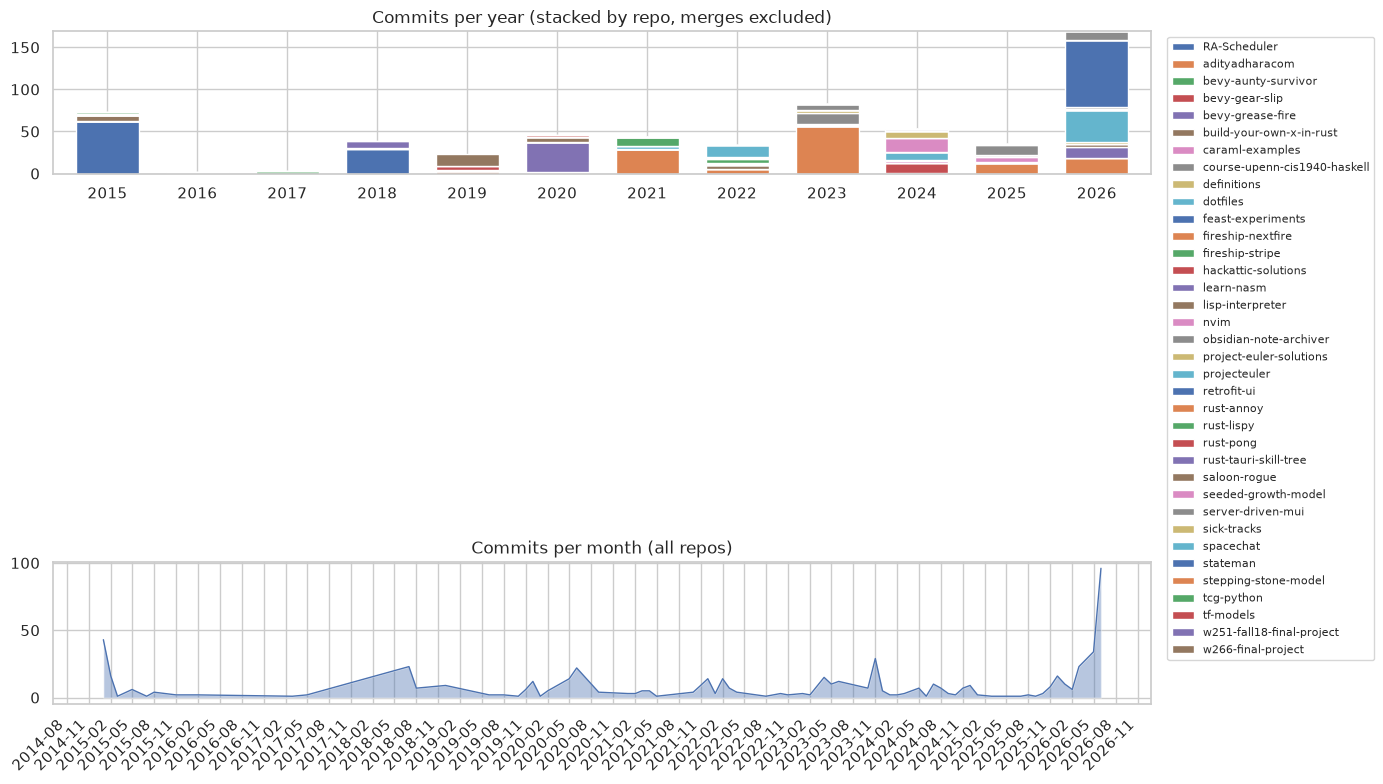

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: commits per year, stacked by repo
by_year_repo = (
    commits_df[~commits_df['is_merge']]
    .groupby(['year', 'repo'])
    .size()
    .unstack(fill_value=0)
)
by_year_repo.plot(kind='bar', stacked=True, ax=axes[0], width=0.7)
axes[0].set_title('Commits per year (stacked by repo, merges excluded)')
axes[0].set_xlabel('')
# axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# Bottom: commits per month (rolling activity)
monthly = (
    commits_df[~commits_df['is_merge']]
    .groupby(commits_df['date'].dt.to_period('M'))
    .size()
    .rename('commits')
)
monthly.index = monthly.index.to_timestamp()
axes[1].fill_between(monthly.index, monthly.values, alpha=0.4)
axes[1].plot(monthly.index, monthly.values, linewidth=1)
axes[1].set_title('Commits per month (all repos)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
save_fig('commits-over-time.png')
plt.show()

### AI co-authorship

In [10]:
ai = commits_df[commits_df['claude_coauthored'] & ~commits_df['is_merge']]
total = commits_df[~commits_df['is_merge']]

print(f'Total non-merge commits: {len(total)}')
print(f'Claude co-authored (tagged): {len(ai)}')
print(f'Percentage tagged: {len(ai)/len(total)*100:.1f}%')
print()
print('Claude-tagged commits:')
print(ai[['repo', 'date', 'message']].to_string(index=False))

Total non-merge commits: 604
Claude co-authored (tagged): 43
Percentage tagged: 7.1%

Claude-tagged commits:
                  repo                      date                                                                                      message
        adityadharacom 2026-06-15 07:34:07+00:00                                                   CI: drop Playwright e2e, run build instead
        adityadharacom 2026-06-15 07:26:00+00:00                                            CI: add 20m timeout and cache Playwright browsers
        adityadharacom 2026-06-14 22:32:56+00:00                                                 Upgrade CI to Node 26 + pnpm 11 via corepack
           retrofit-ui 2026-06-14 20:54:44+00:00                               feat: feat: datetime, date, and time picker field types (#102)
           retrofit-ui 2026-06-14 20:54:16+00:00                          feat: Calendar view for event/scheduling data (CalendarSpec) (#101)
           retrofit-ui 2026-06-14 20:41

/tmp/ipykernel_467230/1380621533.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_all = total.groupby(total['date'].dt.to_period('M')).size()
/tmp/ipykernel_467230/1380621533.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_ai = ai.groupby(ai['date'].dt.to_period('M')).size()


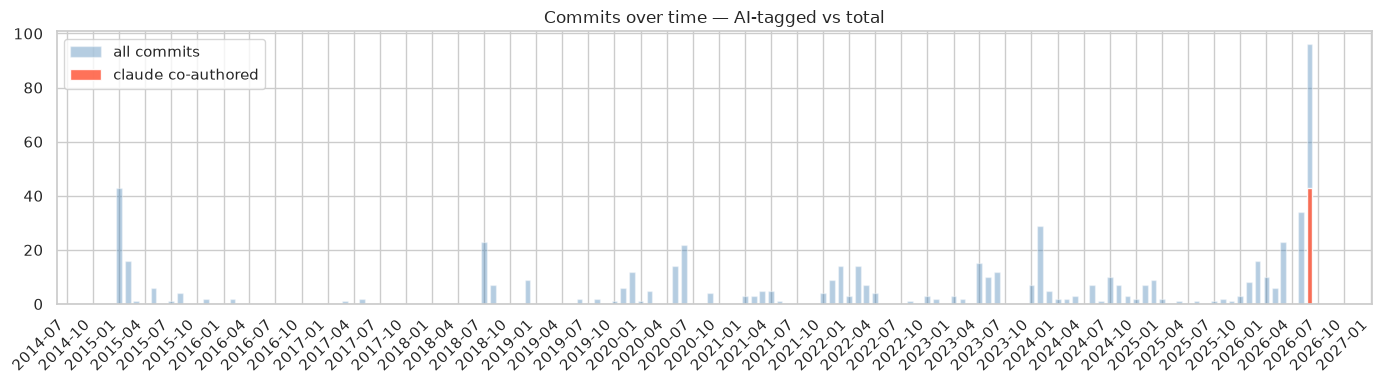

In [11]:
# When did AI tagging start? Plot tagged commits on the timeline
fig, ax = plt.subplots(figsize=(14, 4))

monthly_all = total.groupby(total['date'].dt.to_period('M')).size()
monthly_all.index = monthly_all.index.to_timestamp()
ax.bar(monthly_all.index, monthly_all.values, width=20, alpha=0.4, label='all commits', color='steelblue')

if len(ai) > 0:
    monthly_ai = ai.groupby(ai['date'].dt.to_period('M')).size()
    monthly_ai.index = monthly_ai.index.to_timestamp()
    ax.bar(monthly_ai.index, monthly_ai.values, width=20, alpha=0.9, label='claude co-authored', color='tomato')

ax.set_title('Commits over time — AI-tagged vs total')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
save_fig('ai-tagged.png')
plt.show()

### Attribution breakdown by project

In [12]:
# Per-repo commit counts + Claude attribution
repo_commits = (
    commits_df[~commits_df['is_merge']]
    .groupby('repo')
    .agg(
        total=('sha', 'count'),
        claude=('claude_coauthored', 'sum'),
    )
    .sort_values('total', ascending=False)
)
repo_commits['human'] = repo_commits['total'] - repo_commits['claude']
repo_commits['claude_pct'] = (repo_commits['claude'] / repo_commits['total'] * 100).round(1)

active = repo_commits[repo_commits['total'] >= 5].copy()
print(f"Repos with ≥5 commits: {len(active)}")
print(f"Repos with any Claude co-authorship: {(active['claude'] > 0).sum()}")
print(f"Repos with zero AI: {(active['claude'] == 0).sum()}")
print()
print(active.sort_values('claude', ascending=False)[['total', 'claude', 'claude_pct']].head(20).to_string())

Repos with ≥5 commits: 22
Repos with any Claude co-authorship: 3
Repos with zero AI: 19

                           total  claude  claude_pct
repo                                                
retrofit-ui                   80      39        48.8
adityadharacom               125       3         2.4
obsidian-note-archiver        17       1         5.9
RA-Scheduler                  62       0         0.0
learn-nasm                    35       0         0.0
dotfiles                      49       0         0.0
server-driven-mui             29       0         0.0
stateman                      29       0         0.0
nvim                          24       0         0.0
spacechat                     15       0         0.0
project-euler-solutions       14       0         0.0
w266-final-project            14       0         0.0
bevy-grease-fire              13       0         0.0
bevy-gear-slip                12       0         0.0
rust-lispy                    10       0         0.0
w251-fall1

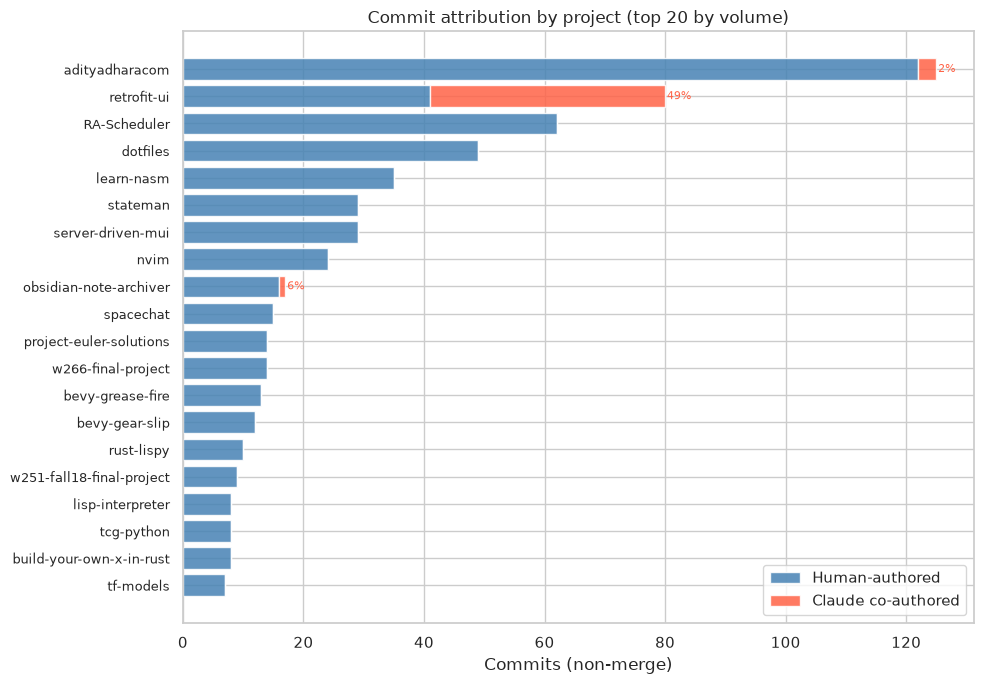

In [13]:
# Chart: attribution breakdown by repo (top 20 by commit volume)
active_sorted = active.sort_values('total', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(active_sorted))
ax.barh(list(y), active_sorted['human'].tolist(), color='steelblue', label='Human-authored', alpha=0.85)
ax.barh(list(y), active_sorted['claude'].tolist(),
        left=active_sorted['human'].tolist(), color='tomato', label='Claude co-authored', alpha=0.85)

ax.set_yticks(list(y))
ax.set_yticklabels(active_sorted.index.tolist(), fontsize=9)
ax.set_xlabel('Commits (non-merge)')
ax.set_title('Commit attribution by project (top 20 by volume)')
ax.legend()

for i, (_, row) in enumerate(active_sorted.iterrows()):
    if row['claude'] > 0:
        ax.text(row['total'] + 0.3, i, f"{row['claude_pct']:.0f}%", va='center', fontsize=8, color='tomato')

plt.tight_layout()
save_fig('attribution-by-repo.png')
plt.show()

### Lines of code vs commit count

In [14]:
non_merge = commits_df[~commits_df['is_merge']]
ai = non_merge[non_merge['claude_coauthored']]
human = non_merge[~non_merge['claude_coauthored']]

# Exclude giant outlier commits (lockfile regenerations, vendored files, etc.)
# Cap at 99th percentile for the per-commit size comparison
p99 = non_merge['lines_changed'].quantile(0.99)
non_merge_trim = non_merge[non_merge['lines_changed'] <= p99]
ai_trim = non_merge_trim[non_merge_trim['claude_coauthored']]
human_trim = non_merge_trim[~non_merge_trim['claude_coauthored']]

print("=== LINES OF CODE COMPARISON (raw) ===")
print(f"Claude commits:  {len(ai):>4}  |  total lines changed: {ai['lines_changed'].sum():>8,}  |  median/commit: {ai['lines_changed'].median():.0f}  |  mean/commit: {ai['lines_changed'].mean():.0f}")
print(f"Human commits:   {len(human):>4}  |  total lines changed: {human['lines_changed'].sum():>8,}  |  median/commit: {human['lines_changed'].median():.0f}  |  mean/commit: {human['lines_changed'].mean():.0f}")
print()
print(f"(99th pct cutoff = {p99:.0f} lines — {len(non_merge) - len(non_merge_trim)} commits excluded from trimmed stats)")
print()
print("=== LINES OF CODE COMPARISON (trimmed, ≤99th pct) ===")
print(f"Claude commits:  {len(ai_trim):>4}  |  median/commit: {ai_trim['lines_changed'].median():.0f}  |  mean/commit: {ai_trim['lines_changed'].mean():.0f}")
print(f"Human commits:   {len(human_trim):>4}  |  median/commit: {human_trim['lines_changed'].median():.0f}  |  mean/commit: {human_trim['lines_changed'].mean():.0f}")
print()
print("=== ATTRIBUTION BY LINES (not commits) ===")
total_lines = non_merge['lines_changed'].sum()
ai_lines = ai['lines_changed'].sum()
print(f"Claude share by lines: {ai_lines:,} of {total_lines:,} = {ai_lines/total_lines*100:.1f}%")
print(f"Claude share by commits: {len(ai)} of {len(non_merge)} = {len(ai)/len(non_merge)*100:.1f}%")

=== LINES OF CODE COMPARISON (raw) ===
Claude commits:    43  |  total lines changed:   41,270  |  median/commit: 496  |  mean/commit: 960
Human commits:    561  |  total lines changed:  392,236  |  median/commit: 60  |  mean/commit: 699

(99th pct cutoff = 9517 lines — 7 commits excluded from trimmed stats)

=== LINES OF CODE COMPARISON (trimmed, ≤99th pct) ===
Claude commits:    42  |  median/commit: 494  |  mean/commit: 756
Human commits:    555  |  median/commit: 58  |  mean/commit: 555

=== ATTRIBUTION BY LINES (not commits) ===
Claude share by lines: 41,270 of 433,506 = 9.5%
Claude share by commits: 43 of 604 = 7.1%


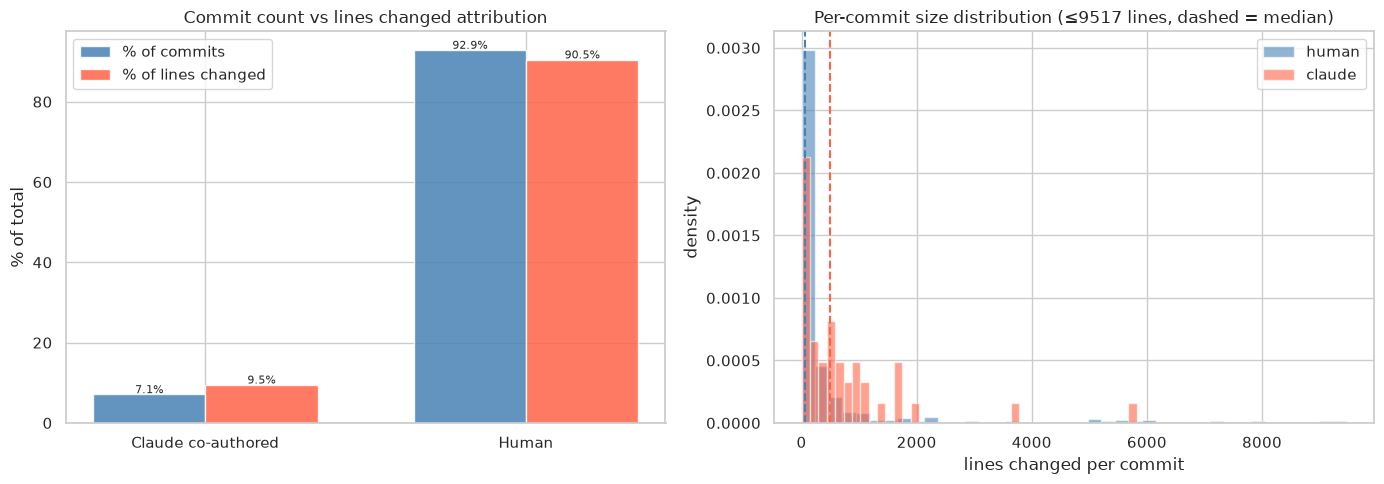

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: commit count vs LOC attribution side-by-side
categories = ['Claude co-authored', 'Human']
commit_counts = [len(ai), len(human)]
loc_totals = [ai['lines_changed'].sum(), human['lines_changed'].sum()]
commit_pcts = [len(ai)/len(non_merge)*100, len(human)/len(non_merge)*100]
loc_pcts = [ai['lines_changed'].sum()/non_merge['lines_changed'].sum()*100,
            human['lines_changed'].sum()/non_merge['lines_changed'].sum()*100]

x = [0, 1]
w = 0.35
axes[0].bar([i - w/2 for i in x], commit_pcts, width=w, label='% of commits', color='steelblue', alpha=0.85)
axes[0].bar([i + w/2 for i in x], loc_pcts, width=w, label='% of lines changed', color='tomato', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('% of total')
axes[0].set_title('Commit count vs lines changed attribution')
axes[0].legend()
for i, (cp, lp) in enumerate(zip(commit_pcts, loc_pcts)):
    axes[0].text(i - w/2, cp + 0.3, f'{cp:.1f}%', ha='center', fontsize=8)
    axes[0].text(i + w/2, lp + 0.3, f'{lp:.1f}%', ha='center', fontsize=8)

# Right: per-commit size distribution (trimmed)
axes[1].hist(human_trim['lines_changed'], bins=40, alpha=0.6, label='human', color='steelblue', density=True)
axes[1].hist(ai_trim['lines_changed'], bins=40, alpha=0.6, label='claude', color='tomato', density=True)
axes[1].axvline(human_trim['lines_changed'].median(), color='steelblue', linestyle='--', linewidth=1.5)
axes[1].axvline(ai_trim['lines_changed'].median(), color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('lines changed per commit')
axes[1].set_ylabel('density')
axes[1].set_title(f'Per-commit size distribution (≤{p99:.0f} lines, dashed = median)')
axes[1].legend()

plt.tight_layout()
save_fig('loc-vs-commits.png')
plt.show()

### PR velocity

/tmp/ipykernel_467230/271808758.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = merged.groupby(merged['merged_at'].dt.to_period('M')).size()


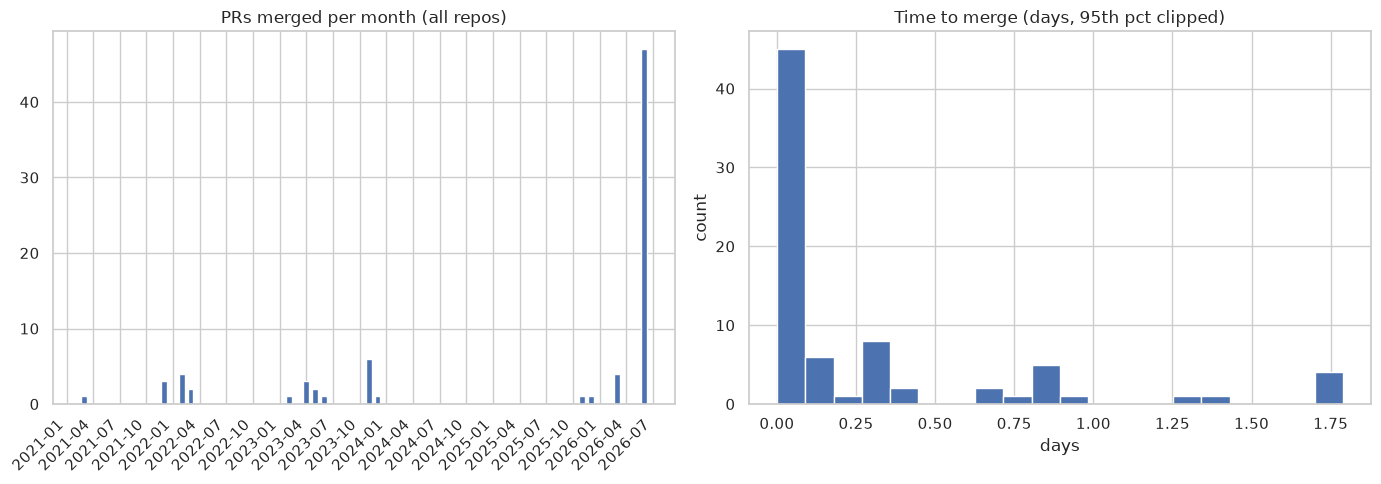

Median time to merge: 0.0 days
Same-day merges (<1 day): 71 of 77


In [16]:
merged = prs_df[prs_df['merged_at'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PRs merged per month
by_month = merged.groupby(merged['merged_at'].dt.to_period('M')).size()
by_month.index = by_month.index.to_timestamp()
axes[0].bar(by_month.index, by_month.values, width=20)
axes[0].set_title('PRs merged per month (all repos)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Time to merge distribution
ttm = merged['time_to_merge_days'].dropna()
ttm_clipped = ttm.clip(upper=ttm.quantile(0.95))
axes[1].hist(ttm_clipped, bins=20, edgecolor='white')
axes[1].set_title('Time to merge (days, 95th pct clipped)')
axes[1].set_xlabel('days')
axes[1].set_ylabel('count')

plt.tight_layout()
save_fig('pr-velocity.png')
plt.show()

print(f'Median time to merge: {ttm.median():.1f} days')
print(f'Same-day merges (<1 day): {(ttm < 1).sum()} of {len(ttm)}')

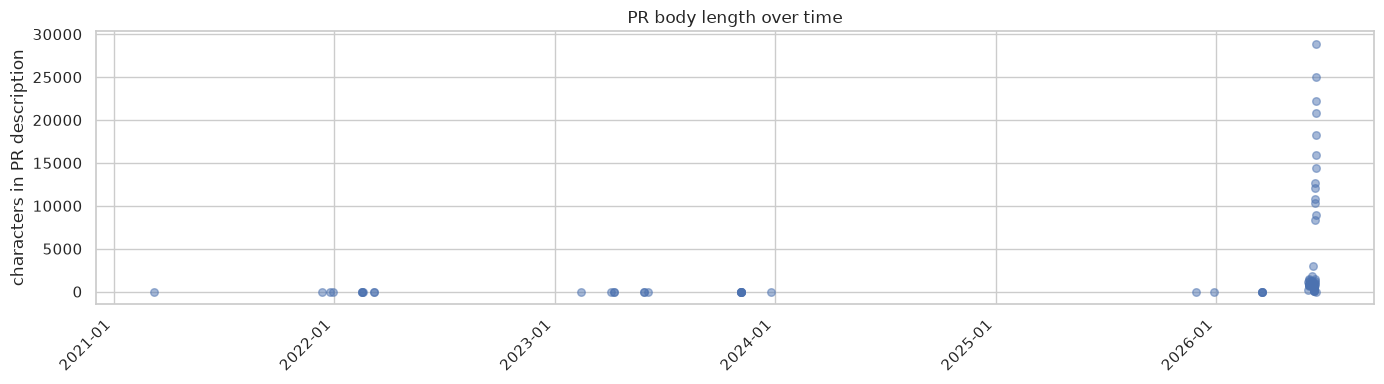

In [17]:
# PR description length over time — does writing get lazier as pace increases?
merged_sorted = merged.sort_values('merged_at')

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(merged_sorted['merged_at'], merged_sorted['body_length'], alpha=0.5, s=30)
ax.set_title('PR body length over time')
ax.set_ylabel('characters in PR description')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### PR documentation quality trend

/tmp/ipykernel_467230/1662385365.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  merged_sorted['quarter'] = merged_sorted['merged_at'].dt.to_period('Q')


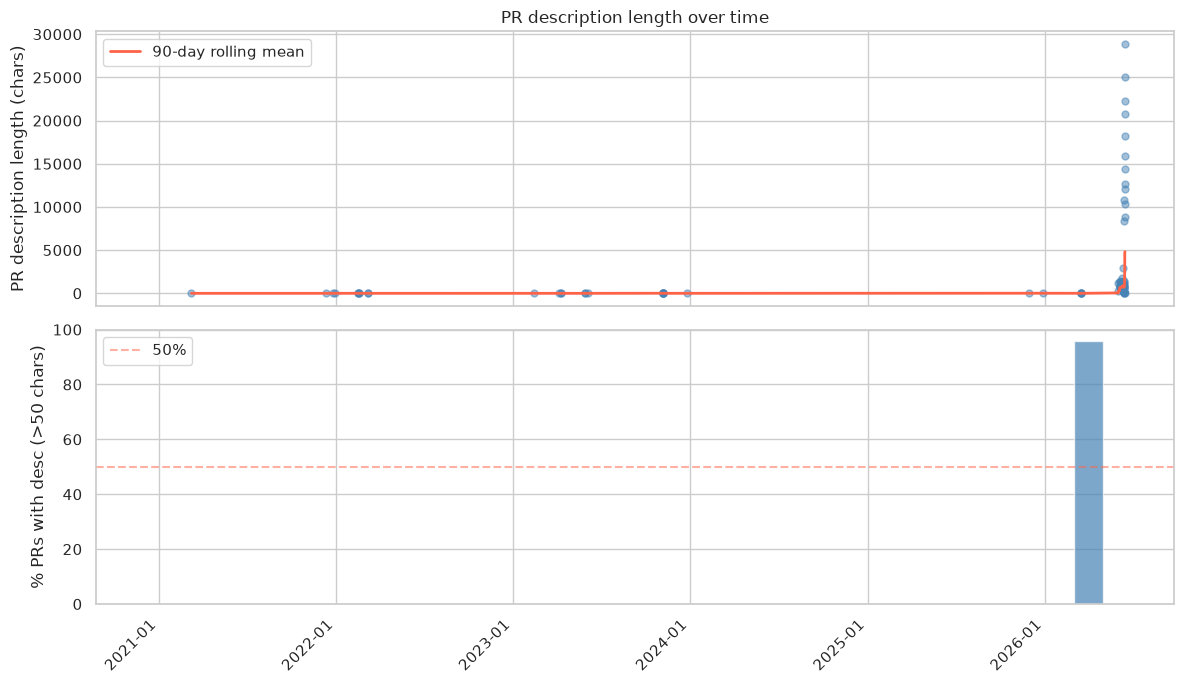

All-time: 58% of PRs have a description (>50 chars)
Since Jan 2026: 88% of PRs have a description
Recent PRs with empty body: 5 of 51


In [18]:
merged_sorted = merged.sort_values('merged_at').copy()
merged_sorted['has_description'] = merged_sorted['body_length'] > 50

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: body length scatter with 90-day rolling mean
axes[0].scatter(merged_sorted['merged_at'], merged_sorted['body_length'],
                alpha=0.5, s=25, color='steelblue')
rolling = merged_sorted.set_index('merged_at')['body_length'].rolling('90D').mean()
axes[0].plot(rolling.index, rolling.values, color='tomato', linewidth=2, label='90-day rolling mean')
axes[0].set_ylabel('PR description length (chars)')
axes[0].set_title('PR description length over time')
axes[0].legend()

# Bottom: % PRs with meaningful description per quarter
merged_sorted['quarter'] = merged_sorted['merged_at'].dt.to_period('Q')
by_quarter = merged_sorted.groupby('quarter').agg(
    total=('number', 'count'),
    with_desc=('has_description', 'sum'),
)
by_quarter['pct'] = by_quarter['with_desc'] / by_quarter['total'] * 100
by_quarter.index = by_quarter.index.to_timestamp()
axes[1].bar(by_quarter.index, by_quarter['pct'], width=60, color='steelblue', alpha=0.7)
axes[1].axhline(50, color='tomato', linestyle='--', alpha=0.5, label='50%')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('% PRs with desc (>50 chars)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
save_fig('pr-docs-trend.png')
plt.show()

print(f"All-time: {merged_sorted['has_description'].mean()*100:.0f}% of PRs have a description (>50 chars)")
recent = merged_sorted[merged_sorted['merged_at'] >= '2026-01-01']
print(f"Since Jan 2026: {recent['has_description'].mean()*100:.0f}% of PRs have a description")
print(f"Recent PRs with empty body: {(recent['body_length'] == 0).sum()} of {len(recent)}")

### Issues — backlog health

/tmp/ipykernel_467230/2546288642.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_month = issues_df.groupby(issues_df['created_at'].dt.to_period('M')).size()


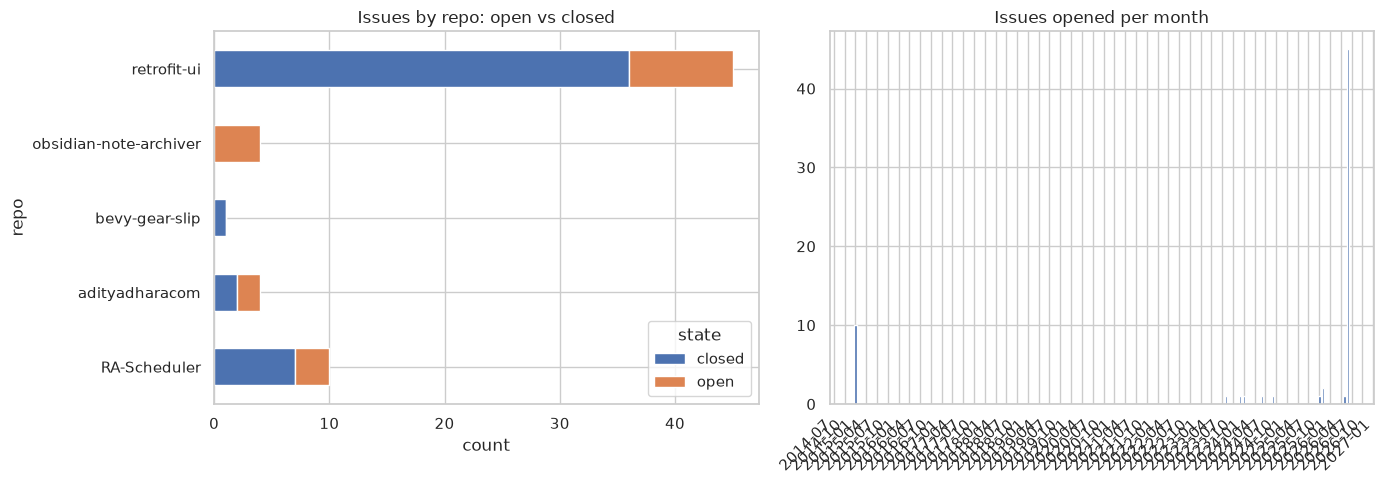

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Open vs closed by repo
issue_state = issues_df.groupby(['repo', 'state']).size().unstack(fill_value=0)
issue_state.plot(kind='barh', stacked=True, ax=axes[0])
axes[0].set_title('Issues by repo: open vs closed')
axes[0].set_xlabel('count')

# Issues opened per month
by_month = issues_df.groupby(issues_df['created_at'].dt.to_period('M')).size()
by_month.index = by_month.index.to_timestamp()
axes[1].bar(by_month.index, by_month.values, width=20)
axes[1].set_title('Issues opened per month')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
save_fig('issues.png')
plt.show()

In [20]:
# External contributions — issues opened by others (not you)
external = issues_df[~issues_df['is_mine'] & issues_df['is_mine'].notna()]
print('Issues filed by external contributors:')
print(external[['repo', 'created_at', 'state', 'author', 'title']].to_string(index=False))

Issues filed by external contributors:
                  repo                created_at  state           author                                                                 title
obsidian-note-archiver 2024-06-21 15:16:55+00:00   open   connradolisboa                           Button to return note to original location.
obsidian-note-archiver 2024-01-05 04:37:29+00:00   open            neins                             Archive under heading / select to archive
obsidian-note-archiver 2023-12-17 18:43:47+00:00   open skullbunnygalaxy Allow config option of turning off copying folder path when archiving
obsidian-note-archiver 2023-08-14 05:45:29+00:00   open           jeff-h                                         Archive by note creation date
          RA-Scheduler 2015-01-29 21:43:44+00:00 closed           gbrova                   Menu bar positions should highlight the active page
          RA-Scheduler 2015-01-29 20:06:31+00:00   open           gbrova                               

### Issue ambition over time

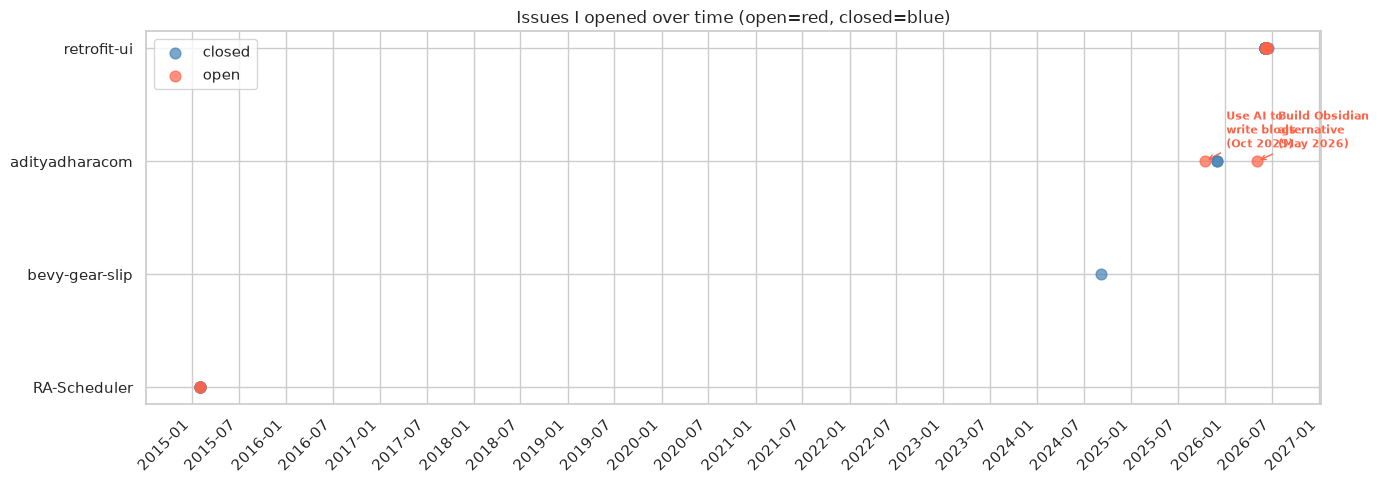

My open issues by repo:
repo
retrofit-ui       9
RA-Scheduler      2
adityadharacom    2

Open issues from external contributors by repo:
repo
RA-Scheduler              1
obsidian-note-archiver    4


In [21]:
from matplotlib.lines import Line2D

my_issues = issues_df[issues_df['is_mine']].copy().sort_values('created_at')

fig, ax = plt.subplots(figsize=(14, 5))

# All my issues as dots coloured by state
colors_map = {'open': 'tomato', 'closed': 'steelblue'}
for state, grp in my_issues.groupby('state'):
    ax.scatter(grp['created_at'], grp['repo'],
               c=colors_map.get(state, 'grey'), s=60, alpha=0.7, zorder=5, label=state)

# Annotate key issues
KEY_ISSUES = {
    'Use llms to generate blogs': 'Use AI to\nwrite blogs\n(Oct 2025)',
    'HOTW: obsidian alternative': 'Build Obsidian\nalternative\n(May 2026)',
}
for _, row in my_issues.iterrows():
    if row['title'] in KEY_ISSUES:
        ax.annotate(
            KEY_ISSUES[row['title']],
            (row['created_at'], row['repo']),
            xytext=(15, 10), textcoords='offset points',
            fontsize=8, color='tomato', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=1),
        )

ax.legend()
ax.set_title('Issues I opened over time (open=red, closed=blue)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_ylabel('')
plt.tight_layout()
save_fig('issue-timeline.png')
plt.show()

print("My open issues by repo:")
print(my_issues[my_issues['state'] == 'open'].groupby('repo').size().sort_values(ascending=False).to_string())
print()
print("Open issues from external contributors by repo:")
ext = issues_df[~issues_df['is_mine'] & issues_df['is_mine'].notna() & (issues_df['state'] == 'open')]
print(ext.groupby('repo').size().to_string())

### Issue velocity — time to close, and retrofit-ui sprint

In [22]:
closed = issues_df[issues_df['closed_at'].notna()].copy()
closed['days_open'] = (closed['closed_at'] - closed['created_at']).dt.total_seconds() / 86400

retrofit_closed = closed[closed['repo'] == 'retrofit-ui'].copy()
other_closed = closed[closed['repo'] != 'retrofit-ui'].copy()

print("=== ISSUE TIME-TO-CLOSE ===")
print(f"All closed issues: {len(closed)}")
print(f"  median days open: {closed['days_open'].median():.1f}")
print(f"  mean days open:   {closed['days_open'].mean():.1f}")
print()
print(f"retrofit-ui closed issues: {len(retrofit_closed)}")
if len(retrofit_closed):
    print(f"  median days open: {retrofit_closed['days_open'].median():.1f}")
    print(f"  mean days open:   {retrofit_closed['days_open'].mean():.1f}")
    print(f"  same-day closes (<1 day): {(retrofit_closed['days_open'] < 1).sum()} of {len(retrofit_closed)}")
print()
print(f"other repos closed issues: {len(other_closed)}")
if len(other_closed):
    print(f"  median days open: {other_closed['days_open'].median():.1f}")
    print(f"  mean days open:   {other_closed['days_open'].mean():.1f}")
print()
print("retrofit-ui issues (all):")
print(issues_df[issues_df['repo'] == 'retrofit-ui'][['number', 'title', 'state', 'created_at', 'closed_at']].to_string(index=False))

=== ISSUE TIME-TO-CLOSE ===
All closed issues: 46
  median days open: 1.1
  mean days open:   3.0

retrofit-ui closed issues: 36
  median days open: 1.7
  mean days open:   2.8
  same-day closes (<1 day): 13 of 36

other repos closed issues: 10
  median days open: 0.5
  mean days open:   3.5

retrofit-ui issues (all):
 number                                                                                       title  state                created_at                 closed_at
     93                                           feat: datetime, date, and time picker field types closed 2026-06-14 10:28:57+00:00 2026-06-14 20:54:45+00:00
     66                            feat: autocomplete field type for server-searched reference data   open 2026-06-11 00:39:56+00:00                       NaT
     64                                      Calendar view for event/scheduling data (CalendarSpec) closed 2026-06-09 09:22:35+00:00 2026-06-14 20:54:18+00:00
     63                            Timeline 

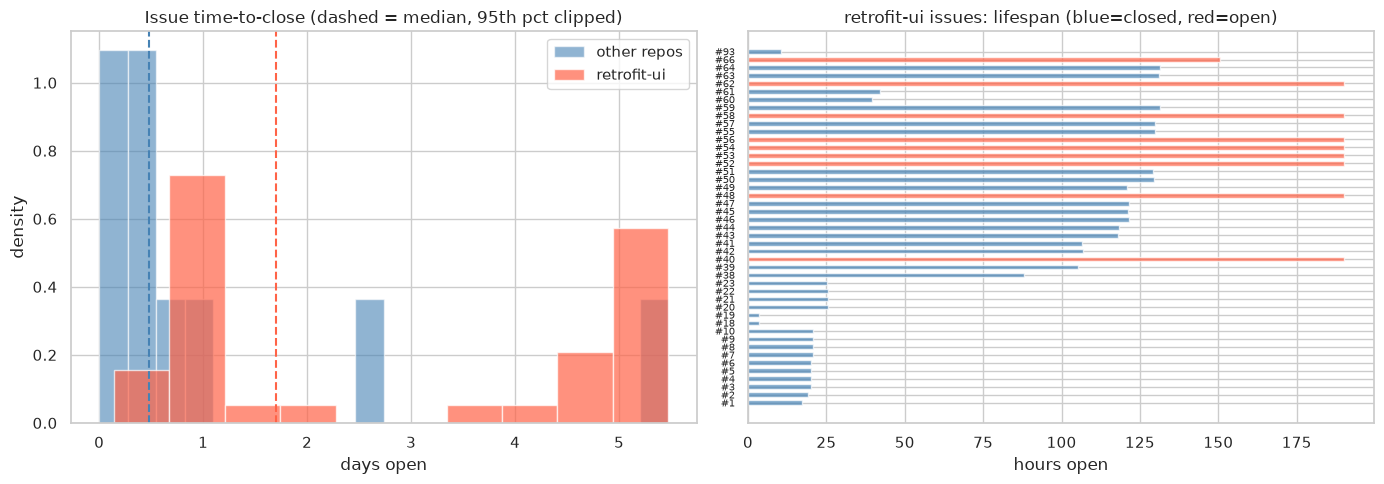

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time-to-close distribution, retrofit-ui vs other
if len(retrofit_closed) and len(other_closed):
    p95 = closed['days_open'].quantile(0.95)
    axes[0].hist(other_closed['days_open'].clip(upper=p95), bins=20, alpha=0.6,
                 label='other repos', color='steelblue', density=True)
    axes[0].hist(retrofit_closed['days_open'].clip(upper=p95), bins=10, alpha=0.7,
                 label='retrofit-ui', color='tomato', density=True)
    axes[0].axvline(other_closed['days_open'].median(), color='steelblue', linestyle='--', linewidth=1.5)
    if len(retrofit_closed) > 1:
        axes[0].axvline(retrofit_closed['days_open'].median(), color='tomato', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel('days open')
    axes[0].set_ylabel('density')
    axes[0].set_title('Issue time-to-close (dashed = median, 95th pct clipped)')
    axes[0].legend()

# Right: retrofit-ui issue creation vs close date (gantt-style)
rui = issues_df[issues_df['repo'] == 'retrofit-ui'].sort_values('created_at').copy()
rui['idx'] = range(len(rui))
colors_state = {'open': 'tomato', 'closed': 'steelblue'}
for _, row in rui.iterrows():
    c = colors_state.get(row['state'], 'grey')
    end = row['closed_at'] if pd.notna(row['closed_at']) else pd.Timestamp.now(tz='UTC')
    axes[1].barh(row['idx'], (end - row['created_at']).total_seconds()/3600,
                 left=0, color=c, alpha=0.7, height=0.6)
axes[1].set_yticks(rui['idx'].tolist())
axes[1].set_yticklabels([f"#{r['number']}" for _, r in rui.iterrows()], fontsize=7)
axes[1].set_xlabel('hours open')
axes[1].set_title('retrofit-ui issues: lifespan (blue=closed, red=open)')

plt.tight_layout()
save_fig('issue-velocity.png')
plt.show()

Pearson r (body_len vs days_open): -0.042  (p=0.782, n=46)
retrofit-ui only: r=-0.023  (p=0.896, n=36)


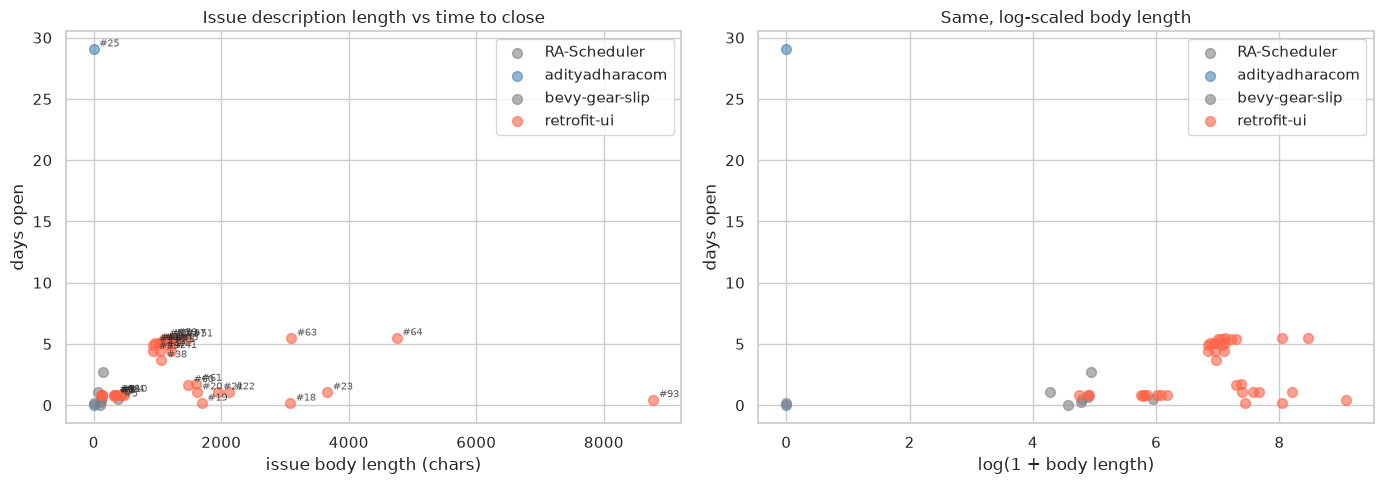

In [24]:
# Issue description length vs time to close
closed = issues_df[issues_df['closed_at'].notna()].copy()
closed['days_open'] = (closed['closed_at'] - closed['created_at']).dt.total_seconds() / 86400

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_repo = {'retrofit-ui': 'tomato', 'adityadharacom': 'steelblue'}
for repo, grp in closed.groupby('repo'):
    c = colors_repo.get(repo, 'grey')
    axes[0].scatter(grp['body_len'], grp['days_open'],
                    color=c, alpha=0.6, s=50, label=repo)
    # annotate outliers (long open or long description)
    for _, row in grp.iterrows():
        if row['days_open'] > 5 or row['body_len'] > 300:
            axes[0].annotate(f"#{int(row['number'])}",
                             (row['body_len'], row['days_open']),
                             fontsize=7, alpha=0.75,
                             xytext=(4, 2), textcoords='offset points')

axes[0].set_xlabel('issue body length (chars)')
axes[0].set_ylabel('days open')
axes[0].set_title('Issue description length vs time to close')
axes[0].legend()

# Right: same but log-scaled body_len to spread out the mass of short issues
import numpy as np
for repo, grp in closed.groupby('repo'):
    c = colors_repo.get(repo, 'grey')
    axes[1].scatter(np.log1p(grp['body_len']), grp['days_open'],
                    color=c, alpha=0.6, s=50, label=repo)

axes[1].set_xlabel('log(1 + body length)')
axes[1].set_ylabel('days open')
axes[1].set_title('Same, log-scaled body length')
axes[1].legend()

# Print a quick correlation
from scipy import stats as sp_stats
if len(closed) > 3:
    r, p = sp_stats.pearsonr(closed['body_len'], closed['days_open'])
    print(f"Pearson r (body_len vs days_open): {r:.3f}  (p={p:.3f}, n={len(closed)})")
    rui = closed[closed['repo'] == 'retrofit-ui']
    if len(rui) > 3:
        r2, p2 = sp_stats.pearsonr(rui['body_len'], rui['days_open'])
        print(f"retrofit-ui only: r={r2:.3f}  (p={p2:.3f}, n={len(rui)})")

plt.tight_layout()
save_fig('issue-complexity-vs-time.png')
plt.show()

### Commit message patterns

Quick look at vocabulary — what words come up most in commit messages?

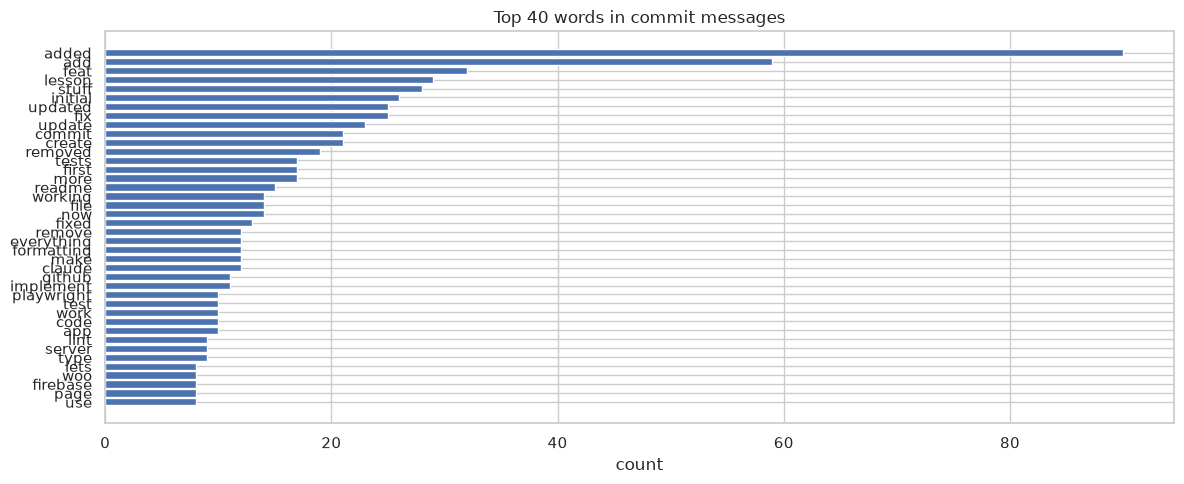

In [25]:
from collections import Counter
import re

STOPWORDS = {
    'and', 'the', 'to', 'a', 'of', 'in', 'for', 'is', 'it', 'this',
    'with', 'on', 'that', 'from', 'up', 'some', 'was', 'be', 'are',
    'all', 'not', 'as', 'an', 'or', 'at', 'by', 'we', 'have', 'merge',
    'pull', 'request', 'branch', 'into', 'main',
}

words = Counter()
for msg in commits_df[~commits_df['is_merge']]['message']:
    tokens = re.findall(r'[a-z]+', str(msg).lower())
    words.update(t for t in tokens if t not in STOPWORDS and len(t) > 2)

top = words.most_common(40)
fig, ax = plt.subplots(figsize=(12, 5))
labels, counts = zip(*top)
ax.barh(labels[::-1], counts[::-1])
ax.set_title('Top 40 words in commit messages')
ax.set_xlabel('count')
plt.tight_layout()
plt.show()

---
## Scratch space

Add cells here for blog-specific stats or one-off queries.

In [26]:
# Example: which month had the most commits?
commits_df[~commits_df['is_merge']].groupby('month').size().sort_values(ascending=False).head(10)

month
2026-06    96
2015-01    43
2026-05    34
2023-11    29
2018-07    23
2026-03    23
2020-06    22
2025-12    16
2015-02    16
2023-04    15
Freq: M, dtype: int64

### Sprint velocity — commit density by repo

Which projects happened in concentrated bursts vs slow drips?

In [27]:
# Sprint stats per repo: total commits, active days, commits/day during active period
def sprint_stats(repo_name):
    df = commits_df[(commits_df['repo'] == repo_name) & ~commits_df['is_merge']]
    if df.empty:
        return None
    span = (df['date'].max() - df['date'].min()).days or 1
    active_days = df['date'].dt.date.nunique()
    return {
        'repo': repo_name,
        'commits': len(df),
        'span_days': span,
        'active_days': active_days,
        'commits_per_active_day': round(len(df) / active_days, 1),
        'first': df['date'].min().date(),
        'last': df['date'].max().date(),
        'claude_pct': round(df['claude_coauthored'].mean() * 100, 0),
    }

SPRINT_REPOS = ['retrofit-ui', 'adityadharacom', 'obsidian-note-archiver', 'bevy-grease-fire', 'fins']
SPRINT_REPOS = [r for r in SPRINT_REPOS if r in commits_df['repo'].unique()]

stats = [sprint_stats(r) for r in SPRINT_REPOS]
stats_df = pd.DataFrame([s for s in stats if s])
print(stats_df.to_string(index=False))
print()
# Check if minnie exists in any form
minnie_check = commits_df[commits_df['repo'].str.contains('minnie', case=False, na=False)]
if len(minnie_check):
    print(f"'minnie' repos found: {minnie_check['slug'].unique()}")
else:
    print("No 'minnie' repo found in fetched data (likely private — query uses privacy: PUBLIC)")

                  repo  commits  span_days  active_days  commits_per_active_day      first       last  claude_pct
           retrofit-ui       80         11           10                     8.0 2026-06-03 2026-06-15        49.0
        adityadharacom      125       2102           32                     3.9 2020-09-12 2026-06-15         2.0
obsidian-note-archiver       17       1103            7                     2.4 2023-05-24 2026-06-01         6.0
      bevy-grease-fire       13          1            2                     6.5 2026-05-30 2026-06-01         0.0

No 'minnie' repo found in fetched data (likely private — query uses privacy: PUBLIC)


/tmp/ipykernel_467230/3544573000.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  weekly = repo_df.groupby(repo_df['date'].dt.to_period('W')).size()
/tmp/ipykernel_467230/3544573000.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  weekly = repo_df.groupby(repo_df['date'].dt.to_period('W')).size()
/tmp/ipykernel_467230/3544573000.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  weekly = repo_df.groupby(repo_df['date'].dt.to_period('W')).size()
/tmp/ipykernel_467230/3544573000.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  weekly = repo_df.groupby(repo_df['date'].dt.to_period('W')).size()


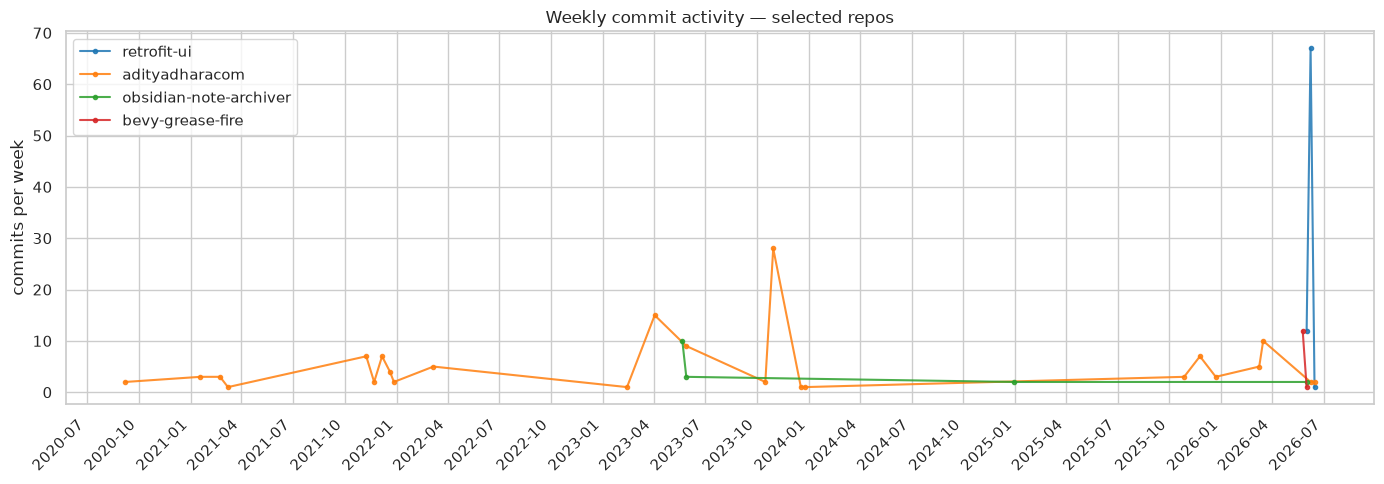

In [28]:
# Weekly commit activity for selected repos
fig, ax = plt.subplots(figsize=(14, 5))

colors = plt.cm.tab10.colors
for i, repo in enumerate(SPRINT_REPOS):
    repo_df = commits_df[(commits_df['repo'] == repo) & ~commits_df['is_merge']]
    if repo_df.empty:
        continue
    weekly = repo_df.groupby(repo_df['date'].dt.to_period('W')).size()
    weekly.index = weekly.index.to_timestamp()
    ax.plot(weekly.index, weekly.values, marker='o', markersize=3,
            label=repo, color=colors[i], linewidth=1.5, alpha=0.85)

ax.set_title('Weekly commit activity — selected repos')
ax.set_ylabel('commits per week')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
save_fig('sprint-velocity.png')
plt.show()

### Summary stats for blog post

In [29]:
print("=== SUMMARY STATS FOR BLOG POST ===\n")

non_merge = commits_df[~commits_df['is_merge']]
ai_tagged = non_merge[non_merge['claude_coauthored']]
merged_prs = prs_df[prs_df['merged_at'].notna()]
ttm = merged_prs['time_to_merge_days'].dropna()
my_issues_all = issues_df[issues_df['is_mine']]
ext_open = issues_df[~issues_df['is_mine'] & issues_df['is_mine'].notna() & (issues_df['state'] == 'open')]

print(f"Commits (non-merge): {len(non_merge)} across {commits_df['repo'].nunique()} repos")
print(f"Claude-tagged: {len(ai_tagged)} ({len(ai_tagged)/len(non_merge)*100:.1f}%)")
print(f"  adityadharacom: {non_merge[non_merge['repo']=='adityadharacom']['claude_coauthored'].sum()} tagged (all CI)")
print(f"  retrofit-ui:    {non_merge[non_merge['repo']=='retrofit-ui']['claude_coauthored'].sum()} tagged (all features)")
print(f"  obsidian-note-archiver: {non_merge[non_merge['repo']=='obsidian-note-archiver']['claude_coauthored'].sum()} tagged")
print()
print(f"Total PRs: {len(prs_df)} | Merged: {len(merged_prs)}")
print(f"Median time to merge: {ttm.median():.1f} days")
print(f"Same-day merges (<1 day): {(ttm < 1).sum()} of {len(ttm)}")
recent_prs = merged_prs[merged_prs['merged_at'] >= '2026-01-01']
print(f"PRs since Jan 2026: {len(recent_prs)}, empty body: {(recent_prs['body_length'] == 0).sum()}")
print()
print(f"My issues: {len(my_issues_all)} ({my_issues_all['state'].eq('open').sum()} open)")
print(f"External open issues: {len(ext_open)} (all on obsidian-note-archiver)")
print()
print("Active repos (≥5 commits) with zero AI:")
zero_ai = active[active['claude'] == 0]
print(zero_ai.sort_values('total', ascending=False)[['total']].head(10).to_string())

=== SUMMARY STATS FOR BLOG POST ===

Commits (non-merge): 604 across 36 repos
Claude-tagged: 43 (7.1%)
  adityadharacom: 3 tagged (all CI)
  retrofit-ui:    39 tagged (all features)
  obsidian-note-archiver: 1 tagged

Total PRs: 100 | Merged: 77
Median time to merge: 0.0 days
Same-day merges (<1 day): 71 of 77
PRs since Jan 2026: 51, empty body: 5

My issues: 57 (13 open)
External open issues: 5 (all on obsidian-note-archiver)

Active repos (≥5 commits) with zero AI:
                         total
repo                          
RA-Scheduler                62
dotfiles                    49
learn-nasm                  35
server-driven-mui           29
stateman                    29
nvim                        24
spacechat                   15
project-euler-solutions     14
w266-final-project          14
bevy-grease-fire            13
